# LAB 1: Regression 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

### ขั้นตอนที่ 1: Load Dataset และเลือกเฉพาะ DC

In [13]:
df = pd.read_csv('comic_characters.csv')
print("จำนวนข้อมูลทั้งหมด:", df.shape)

dc = df[df['Universe'] == 'DC'].copy()
print("จำนวนข้อมูลเฉพาะ DC:", dc.shape)
dc.head()

จำนวนข้อมูลทั้งหมด: (21144, 12)
จำนวนข้อมูลเฉพาะ DC: (6479, 12)


,Id,Name,Identity,Alignment,Eyes,Hair,Sex,Alive,Appearances,First_appeared,Planet,Universe
2,2,John Malone,Secret,Bad,Blue,White,Male,Yes,15,"1985, January",New Earth,DC
3,3,"Samuel Bradley, Jr.",Public,Bad,Brown,Brown,Male,No,19,"2004, March",New Earth,DC
4,4,Hope Taya,Public,Bad,Brown,Black,Female,Yes,28,"1999, December",New Earth,DC
5,5,Trygg,Secret,Bad,Black,Black,Male,Yes,3,"1940, June",New Earth,DC
6,6,Boris Dmitravich Razumihin,Public,Good,Brown,Black,Male,Yes,7,"1987, December",New Earth,DC


In [19]:
print(dc.info())
print("\nจำนวนค่าว่างในแต่ละคอลัมน์:")
print(dc.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6479 entries, 0 to 6478
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              6479 non-null   int64  
 1   Name            6479 non-null   str    
 2   Identity        6479 non-null   str    
 3   Alignment       6479 non-null   str    
 4   Eyes            6479 non-null   str    
 5   Hair            6479 non-null   str    
 6   Sex             6479 non-null   str    
 7   Alive           6479 non-null   str    
 8   Appearances     6479 non-null   int64  
 9   First_appeared  6479 non-null   str    
 10  Planet          6479 non-null   str    
 11  Universe        6479 non-null   str    
 12  Year            6479 non-null   float64
 13  Character_Age   6479 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 708.8 KB
None

จำนวนค่าว่างในแต่ละคอลัมน์:
Id                0
Name              0
Identity          0
Alignment         0
Eyes     

### ขั้นตอนที่ 2: Feature Engineering — สร้าง Character_Age

In [14]:
dc['Year'] = dc['First_appeared'].str.extract(r'(\d{4})').astype(float)
dc = dc.dropna(subset=['Year']).reset_index(drop=True)

REFERENCE_YEAR = int(dc['Year'].max())
dc['Character_Age'] = REFERENCE_YEAR - dc['Year']

print("ปีอ้างอิง (Reference Year):", REFERENCE_YEAR)
dc[['Name', 'First_appeared', 'Year', 'Character_Age', 'Appearances']].head()

ปีอ้างอิง (Reference Year): 2013


,Name,First_appeared,Year,Character_Age,Appearances
0,John Malone,"1985, January",1985.0,28.0,15
1,"Samuel Bradley, Jr.","2004, March",2004.0,9.0,19
2,Hope Taya,"1999, December",1999.0,14.0,28
3,Trygg,"1940, June",1940.0,73.0,3
4,Boris Dmitravich Razumihin,"1987, December",1987.0,26.0,7


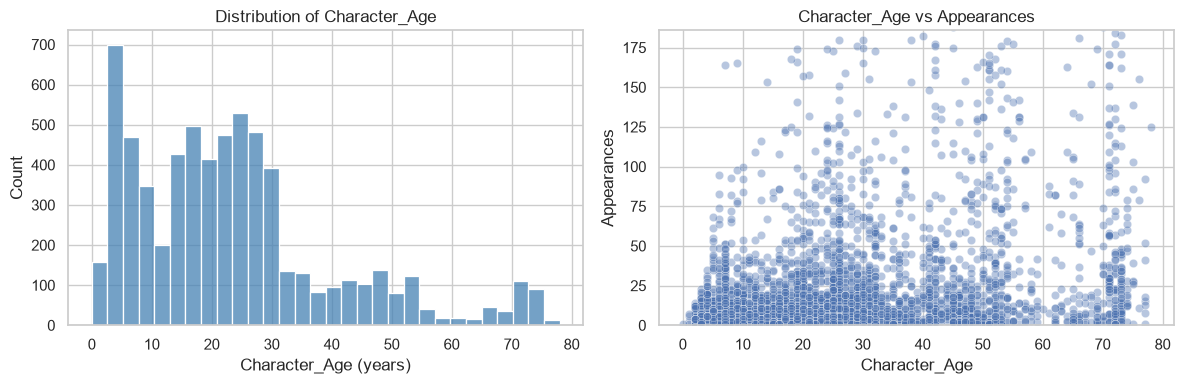

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(dc['Character_Age'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Character_Age')
axes[0].set_xlabel('Character_Age (years)')

sns.scatterplot(data=dc, x='Character_Age', y='Appearances', alpha=0.4, ax=axes[1])
axes[1].set_title('Character_Age vs Appearances')
axes[1].set_ylim(0, dc['Appearances'].quantile(0.98))

plt.tight_layout()
plt.show()

# Simple Linear Regression

In [15]:
X = dc[['Character_Age']]
y = dc['Appearances']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)

y_pred_simple = simple_lr.predict(X_test)

print(f"สมการที่ได้: Appearances = {simple_lr.coef_[0]:.4f} * Character_Age + {simple_lr.intercept_:.4f}")

สมการที่ได้: Appearances = 1.3784 * Character_Age + -7.9396


In [21]:
mse_simple = mean_squared_error(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print(f"MSE : {mse_simple:.2f}")
print(f"MAE : {mae_simple:.2f}")
print(f"R^2 : {r2_simple:.4f}")

MSE : 2979.08
MAE : 25.60
R^2 : 0.0586


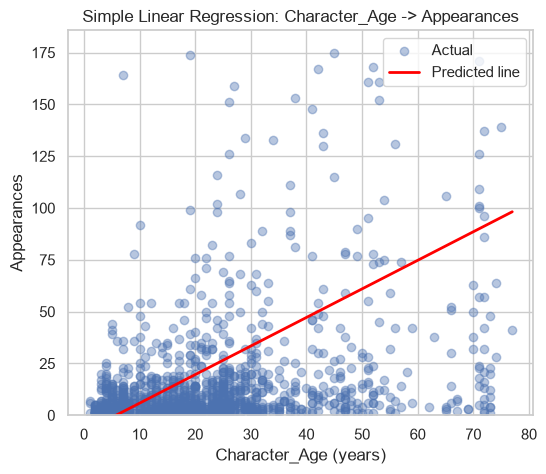

In [22]:
plt.figure(figsize=(6, 5))
plt.scatter(X_test, y_test, alpha=0.4, label='Actual')
order = np.argsort(X_test['Character_Age'].values)
plt.plot(X_test['Character_Age'].values[order], y_pred_simple[order], color='red', linewidth=2, label='Predicted line')
plt.ylim(0, y.quantile(0.98))
plt.xlabel('Character_Age (years)')
plt.ylabel('Appearances')
plt.title('Simple Linear Regression: Character_Age -> Appearances')
plt.legend(['Actual', 'Predicted line'])
plt.show()

# Multiple Linear Regression

In [16]:
cat_features = ['Alignment', 'Identity', 'Sex', 'Alive']
num_features = ['Character_Age']
features_multi = num_features + cat_features

X_multi = dc[features_multi]
y_multi = dc['Appearances']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
], remainder='passthrough')

multi_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('regressor', LinearRegression())
])

Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
multi_pipeline.fit(Xm_train, ym_train)
y_pred_multi = multi_pipeline.predict(Xm_test)

In [23]:
mse_multi = mean_squared_error(ym_test, y_pred_multi)
mae_multi = mean_absolute_error(ym_test, y_pred_multi)
r2_multi = r2_score(ym_test, y_pred_multi)

comparison = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'MSE': [mse_simple, mse_multi],
    'MAE': [mae_simple, mae_multi],
    'R2': [r2_simple, r2_multi]
})
comparison

,Model,MSE,MAE,R2
0,Simple Linear Regression,2979.075436,25.602076,0.058595
1,Multiple Linear Regression,2920.922250,26.426481,0.076971


# Age Prediction

In [17]:
features_age = ['Appearances'] + cat_features
X_age = dc[features_age]
y_age = dc['Character_Age']

preprocess_age = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
], remainder='passthrough')

age_pipeline = Pipeline([
    ('preprocess', preprocess_age),
    ('regressor', LinearRegression())
])

Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_age, y_age, test_size=0.2, random_state=42)
age_pipeline.fit(Xa_train, ya_train)
y_pred_age = age_pipeline.predict(Xa_test)

mse_age = mean_squared_error(ya_test, y_pred_age)
mae_age = mean_absolute_error(ya_test, y_pred_age)
r2_age = r2_score(ya_test, y_pred_age)

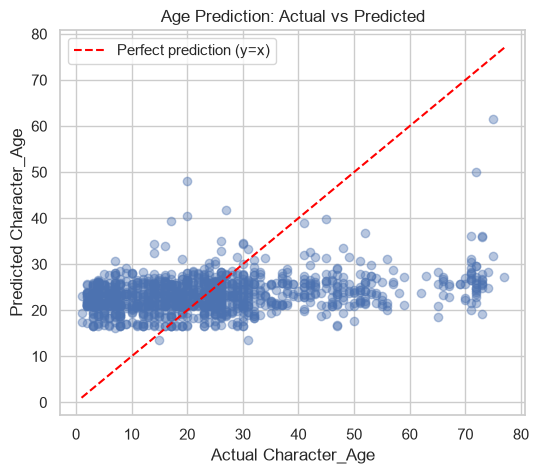

In [24]:
plt.figure(figsize=(6, 5))
plt.scatter(ya_test, y_pred_age, alpha=0.4)
lims = [ya_test.min(), ya_test.max()]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction (y=x)')
plt.xlabel('Actual Character_Age')
plt.ylabel('Predicted Character_Age')
plt.title('Age Prediction: Actual vs Predicted')
plt.legend()
plt.show()